In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import kagglehub

path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Downloaded to:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Downloaded to: /kaggle/input/gtsrb-german-traffic-sign


In [ ]:
TRAIN_DIR   = '/kaggle/input/gtsrb-german-traffic-sign/Train'

TEST_DIR    = '/kaggle/input/gtsrb-german-traffic-sign/Test'
TEST_CSV    = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv'

CLASS_NAMES = {
    0:'Speed limit (20)',    1:'Speed limit (30)',   2:'Speed limit (50)',
    3:'Speed limit (60)',    4:'Speed limit (70)',   5:'Speed limit (80)',
    6:'End speed limit(80)', 7:'Speed limit (100)',  8:'Speed limit (120)',
    9:'No passing',         10:'No passing >3.5t',  11:'Right-of-way',
    12:'Priority road',     13:'Yield',              14:'Stop',
    15:'No vehicles',       16:'No >3.5t vehicles', 17:'No entry',
    18:'General caution',   19:'Danger curve left', 20:'Danger curve right',
    21:'Double curve',      22:'Bumpy road',         23:'Slippery road',
    24:'Road narrows',      25:'Road work',          26:'Traffic signals',
    27:'Pedestrians',       28:'Children crossing',  29:'Bicycles crossing',
    30:'Ice/snow',          31:'Wild animals',       32:'End speed+passing',
    33:'Turn right ahead',  34:'Turn left ahead',    35:'Ahead only',
    36:'Go straight/right', 37:'Go straight/left',   38:'Keep right',
    39:'Keep left',         40:'Roundabout',          41:'End no passing',
    42:'End no passing >3.5t'
}

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

data_list = []
labels_list = []
classes_list = 43
for i in range(classes_list):
    i_path = os.path.join(TRAIN_DIR, str(i)) #0-42
    for img in os.listdir(i_path):
        im = Image.open(i_path +'/'+ img)
        im = im.resize((32,32))
        im = np.array(im)
        data_list.append(im)
        labels_list.append(i)
data = np.array(data_list)
labels = np.array(labels_list)

In [ ]:
np.save('/content/data.npy', data)
np.save('/content/labels.npy', labels)

In [ ]:
!cp /content/data.npy /content/drive/MyDrive/gtsrb_dataset/
!cp /content/labels.npy /content/drive/MyDrive/gtsrb_dataset/

In [ ]:
import numpy as np

data = np.load('/content/drive/MyDrive/gtsrb_dataset/data.npy')
labels = np.load('/content/drive/MyDrive/gtsrb_dataset/labels.npy')

In [ ]:
print(f"Shape của data: {data.shape}")
print(f"Shape của labels: {labels.shape}")

Shape của data: (39209, 32, 32, 3)
Shape của labels: (39209,)


array([[[255, 253, 213],
        [255, 253, 214],
        [255, 251, 215],
        ...,
        [237, 221, 185],
        [235, 219, 184],
        [234, 216, 182]],

       [[255, 255, 229],
        [255, 255, 228],
        [255, 255, 229],
        ...,
        [253, 240, 204],
        [253, 239, 201],
        [253, 238, 201]],

       [[255, 255, 239],
        [255, 255, 237],
        [255, 255, 234],
        ...,
        [255, 246, 205],
        [254, 246, 207],
        [254, 244, 209]],

       ...,

       [[255, 255, 229],
        [255, 255, 226],
        [255, 255, 222],
        ...,
        [183, 172, 142],
        [182, 169, 138],
        [181, 168, 138]],

       [[255, 255, 229],
        [255, 255, 224],
        [255, 255, 222],
        ...,
        [195, 183, 151],
        [192, 180, 150],
        [192, 180, 148]],

       [[255, 255, 227],
        [255, 255, 226],
        [255, 255, 224],
        ...,
        [203, 191, 157],
        [202, 190, 157],
        [201, 187, 155]]], dtype=uint8)
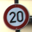

In [ ]:
data[0]

In [ ]:
labels

array([ 0,  0,  0, ..., 42, 42, 42])

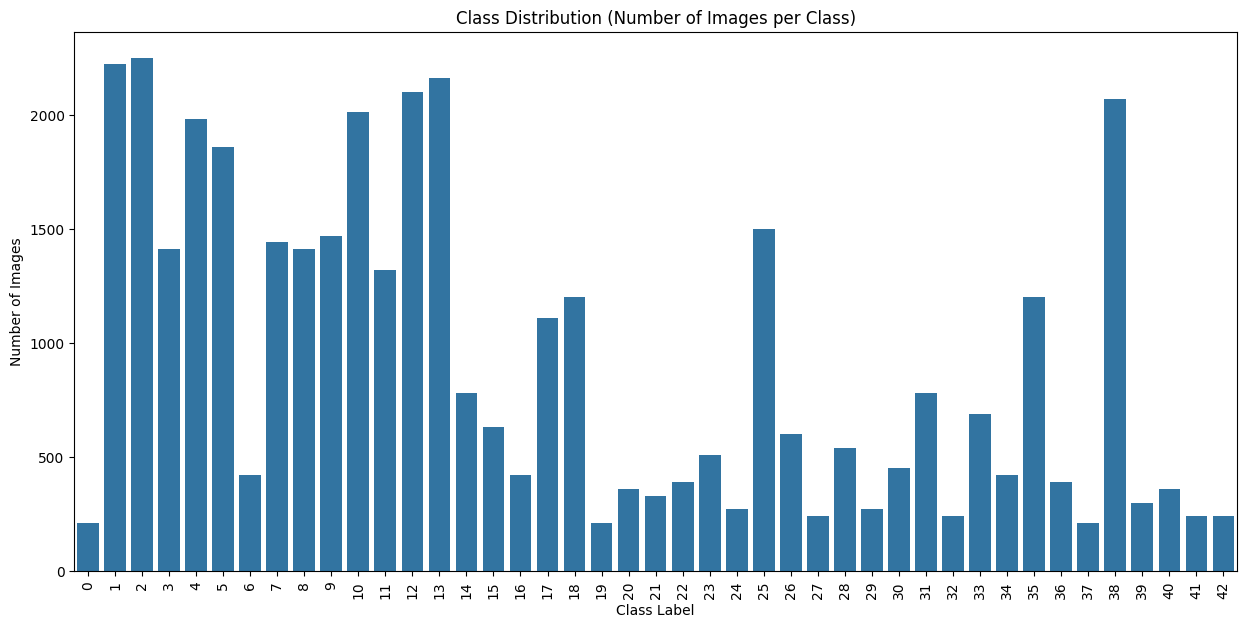

In [ ]:
plt.figure(figsize=(15, 7))
sns.countplot(x=labels)
plt.title('Class Distribution (Number of Images per Class)')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=90)
plt.show()

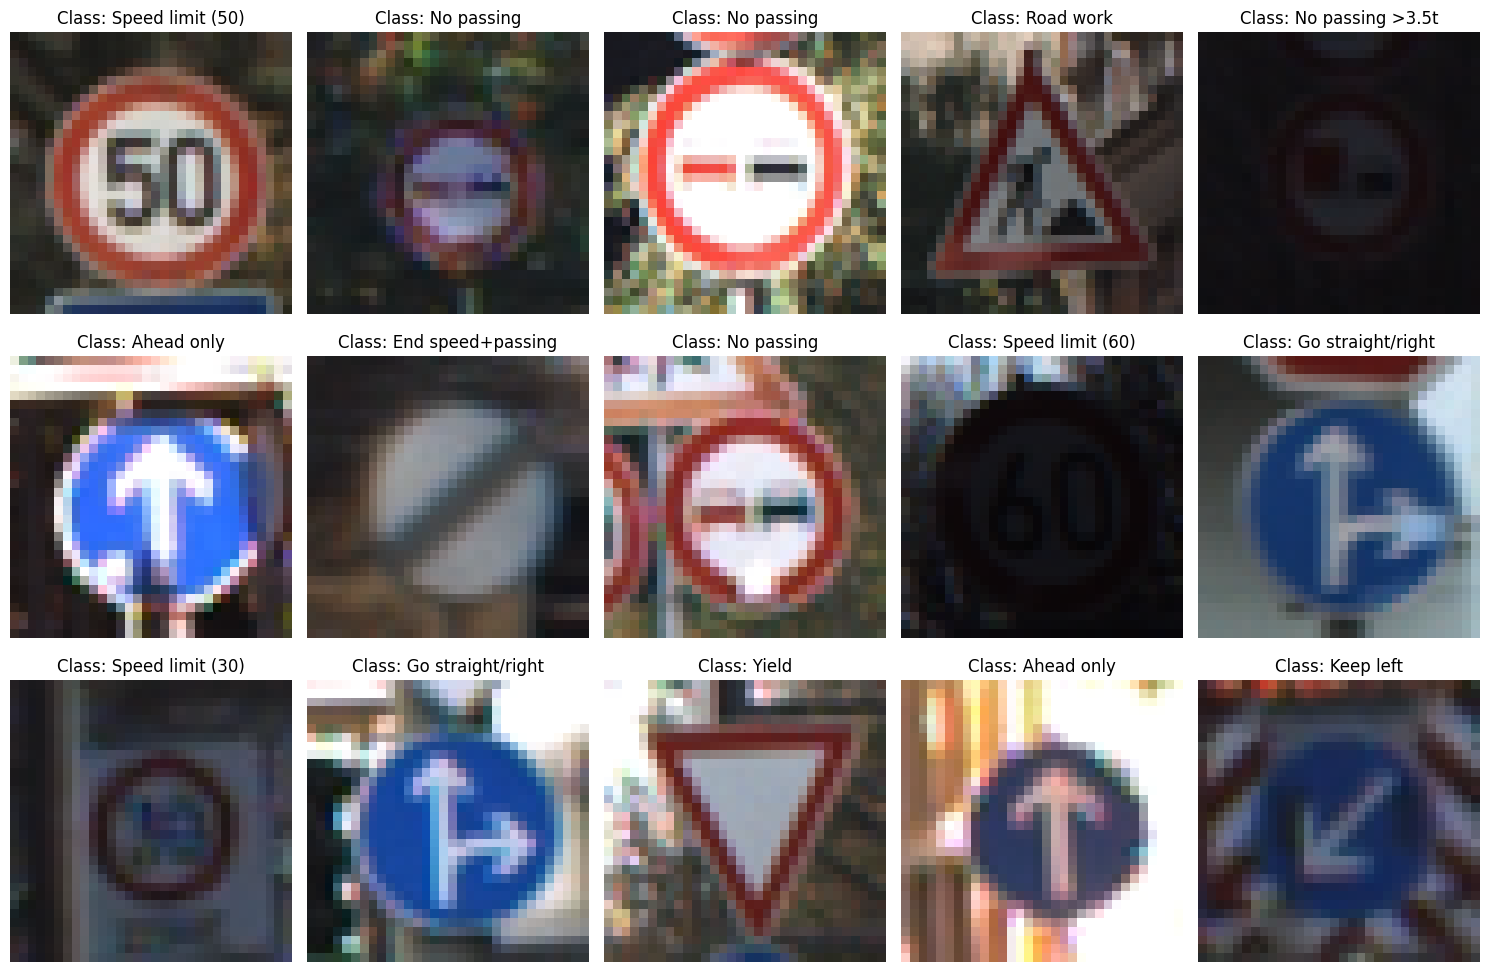

In [ ]:
import random

num_samples = 15

plt.figure(figsize=(15, 10))

for i in range(num_samples):
    index = random.randint(0, len(data) - 1)
    plt.subplot(3, 5, i + 1)
    plt.imshow(data[index])
    plt.title(f"Class: {CLASS_NAMES[labels[index]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# stratify=labels: Giữ nguyên tỷ lệ các lớp trong cả tập huấn luyện và kiểm tra.
# Điều này rất quan trọng khi có sự mất cân bằng giữa các lớp.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)

print(f"Shape của X_train_raw: {X_train_raw.shape}")
print(f"Shape của X_test_raw: {X_test_raw.shape}")
print(f"Shape của y_train: {y_train.shape}")
print(f"Shape của y_test: {y_test.shape}")

Shape của X_train_raw: (31367, 32, 32, 3)
Shape của X_test_raw: (7842, 32, 32, 3)
Shape của y_train: (31367,)
Shape của y_test: (7842,)



Trích xuất đặc trưng HOG là một kỹ thuật phổ biến trong Machine Learning truyền thống để mô tả hình dạng cục bộ và cấu trúc của đối tượng trong ảnh. Nó hoạt động bằng cách tính toán hướng của gradient và xây dựng biểu đồ histogram các hướng đó trong các vùng nhỏ (cells) của ảnh.

Trong bước này, chúng ta sẽ viết một hàm để thực hiện việc này và áp dụng nó cho cả tập huấn luyện và kiểm tra.

In [ ]:
from skimage.feature import hog
from skimage.color import rgb2gray
from tqdm import tqdm
import numpy as np

def extract_hog_features(images):
    """
    Hàm này trích xuất đặc trưng HOG từ một mảng các ảnh màu.

    Args:
        images (np.ndarray): Mảng numpy của các ảnh màu, có shape (số_ảnh, chiều_cao, chiều_rộng, số_kênh).

    Returns:
        np.ndarray: Mảng numpy của các đặc trưng HOG đã được duỗi phẳng cho mỗi ảnh.
    """
    hog_features = []
    # Sử dụng tqdm để hiển thị thanh tiến trình cho quá trình trích xuất đặc trưng
    for img in tqdm(images, desc="Trích xuất HOG"):
        # Chuyển đổi ảnh màu sang ảnh xám để tính toán gradient dễ dàng hơn.
        # HOG thường hoạt động hiệu quả hơn trên ảnh xám vì nó tập trung vào cấu trúc cạnh.
        gray_img = rgb2gray(img)

        # Trích xuất đặc trưng HOG từ ảnh xám.
        # orientations=9: Số lượng thùng (bin) cho histogram hướng gradient. 9 hướng (0-180 độ).
        # pixels_per_cell=(8, 8): Kích thước của mỗi cell (8x8 pixel). Gradient được tính trong từng cell.
        # cells_per_block=(2, 2): Kích thước của mỗi block (2x2 cell). Các block chồng lấn nhau để chuẩn hóa độ tương phản.
        # visualize=False: Không trả về ảnh visualize HOG.
        # multichannel=False (hoặc channel_axis=None): Vì ảnh đã chuyển sang xám nên không có nhiều kênh. (Đã loại bỏ đối số 'multichannel' vì gây lỗi với phiên bản skimage hiện tại)
        # flatten_hog=True: Tự động duỗi phẳng vector HOG cho mỗi ảnh.
        features = hog(gray_img, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=False, feature_vector=True)
        hog_features.append(features)
    return np.array(hog_features)

# Áp dụng hàm trích xuất đặc trưng HOG cho tập huấn luyện và kiểm tra
print("Trích xuất đặc trưng HOG cho tập huấn luyện...")
X_train_hog = extract_hog_features(X_train_raw)

print("Trích xuất đặc trưng HOG cho tập kiểm tra...")
X_test_hog = extract_hog_features(X_test_raw)

# In ra shape của X_train_hog để kiểm tra kích thước vector đặc trưng
print(f"Shape của X_train_hog sau khi trích xuất HOG: {X_train_hog.shape}")
# (Số lượng mẫu huấn luyện, Kích thước vector HOG)
# Kích thước vector HOG = (Số lượng block theo chiều ngang * Số lượng block theo chiều dọc)
#                       * (cells_per_block[0] * cells_per_block[1]) * orientations
# Đối với ảnh 32x32, pixels_per_cell=(8,8), cells_per_block=(2,2):
# (32/8-1)* (32/8-1) * (2*2) * 9 = 3*3*4*9 = 324.
# Do đó, shape dự kiến là (số_mẫu, 324)

Trích xuất đặc trưng HOG cho tập huấn luyện...


Trích xuất HOG: 100%|██████████| 31367/31367 [00:16<00:00, 1935.95it/s]


Trích xuất đặc trưng HOG cho tập kiểm tra...


Trích xuất HOG: 100%|██████████| 7842/7842 [00:03<00:00, 2269.44it/s]


Shape của X_train_hog sau khi trích xuất HOG: (31367, 324)


In [ ]:
X_train_hog[0]

array([0.49391021, 0.09264887, 0.13853127, 0.08793187, 0.04267595,
       0.00504456, 0.01589965, 0.02490162, 0.21290636, 0.08605342,
       0.03206569, 0.04810685, 0.07304544, 0.1063412 , 0.05398627,
       0.06549544, 0.09191256, 0.03762135, 0.49391021, 0.05674049,
       0.1445508 , 0.00530731, 0.03554669, 0.        , 0.02739299,
       0.13424082, 0.29543043, 0.0642117 , 0.029977  , 0.49391021,
       0.05440595, 0.        , 0.01015238, 0.01835407, 0.01308465,
       0.0097102 , 0.0623959 , 0.02325029, 0.03488147, 0.05296403,
       0.07710623, 0.03914455, 0.04748965, 0.06664426, 0.02727861,
       0.44700007, 0.05909221, 0.09575472, 0.00448882, 0.01067519,
       0.00162097, 0.01551514, 0.05951064, 0.44700007, 0.04655883,
       0.02173582, 0.44700007, 0.03944885, 0.        , 0.00736132,
       0.01330823, 0.00948746, 0.0070407 , 0.01629966, 0.04357501,
       0.25835839, 0.05875554, 0.15542461, 0.05944571, 0.44700007,
       0.20227115, 0.12358185, 0.34882587, 0.05281748, 0.08558

In [ ]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_hog)
X_test_scaled = scaler.transform(X_test_hog)

# In ra giá trị mean và variance của một vài đặc trưng ngẫu nhiên trong X_train_scaled để xác nhận.
num_features_to_check = 5
random_feature_indices = np.random.choice(X_train_scaled.shape[1], num_features_to_check, replace=False)

for i, idx in enumerate(random_feature_indices):
    feature_mean = np.mean(X_train_scaled[:, idx])
    feature_variance = np.var(X_train_scaled[:, idx])
    print(f"Đặc trưng ngẫu nhiên {i+1} (chỉ số {idx}): Mean = {feature_mean:.4f}, Variance = {feature_variance:.4f}")

print(f"\nShape của X_train_scaled: {X_train_scaled.shape}")
print(f"Shape của X_test_scaled: {X_test_scaled.shape}")

Đặc trưng ngẫu nhiên 1 (chỉ số 23): Mean = -0.0000, Variance = 1.0000
Đặc trưng ngẫu nhiên 2 (chỉ số 103): Mean = 0.0000, Variance = 1.0000
Đặc trưng ngẫu nhiên 3 (chỉ số 153): Mean = -0.0000, Variance = 1.0000
Đặc trưng ngẫu nhiên 4 (chỉ số 323): Mean = 0.0000, Variance = 1.0000
Đặc trưng ngẫu nhiên 5 (chỉ số 47): Mean = -0.0000, Variance = 1.0000

Shape của X_train_scaled: (31367, 324)
Shape của X_test_scaled: (7842, 324)


In [ ]:
import time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("Bước 1: Lấy mẫu phụ (Subsampling) để Tuning...")
# Tính toán 10% số lượng mẫu từ X_train_scaled
num_samples_tune = int(X_train_scaled.shape[0] * 0.1)

# Trích xuất ngẫu nhiên khoảng 10% dữ liệu từ X_train_scaled và y_train
X_tune, _, y_tune, _ = train_test_split(
    X_train_scaled, y_train, train_size=num_samples_tune, stratify=y_train, random_state=42
)

print(f"  Shape của X_tune: {X_tune.shape}")
print(f"  Shape của y_tune: {y_tune.shape}\n")

print("Tìm kiếm lưới (GridSearchCV) trên tập Subsample...")
start_time_gridsearch = time.time()

# Khởi tạo mô hình SVC
svc_model = SVC(class_weight='balanced', random_state=42)

# Định nghĩa không gian tìm kiếm siêu tham số
param_grid = [
    {'kernel': ['linear'],
     'C': [0.1, 1, 10]
     },
    {'kernel': ['rbf'],
     'C': [0.1, 1, 10],
     'gamma': ['scale', 0.01, 0.001]},
    {'kernel': ['poly'],
     'C': [0.1, 1],
     'degree': [2, 3],
     'gamma': ['scale']},
    {'kernel': ['sigmoid'],
     'C': [0.1, 1],
     'gamma': ['scale']}
]

# Khởi tạo GridSearchCV
grid_search = GridSearchCV(
    estimator=svc_model,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Tiến hành .fit() trên tập (X_tune, y_tune)
grid_search.fit(X_tune, y_tune)

print("Kết thúc GridSearchCV. Bộ tham số tốt nhất là:", grid_search.best_params_)

# Tạo pandas DataFrame từ grid.cv_results_
results_df = pd.DataFrame(grid_search.cv_results_)

# Chỉ lấy các cột được yêu cầu
columns_to_display = [
    'param_kernel', 'param_C', 'param_gamma', 'param_degree',
    'mean_test_score', 'std_test_score', 'mean_fit_time'
]

# Kiểm tra và thêm các cột nếu chúng tồn tại (gamma, degree chỉ có với một số kernel)
actual_columns = [col for col in columns_to_display if col in results_df.columns]
filtered_results_df = results_df[actual_columns]

# Sắp xếp bảng theo mean_test_score giảm dần
filtered_results_df = filtered_results_df.sort_values(by='mean_test_score', ascending=False)

print("Top 10 cấu hình tốt nhất:")
display(filtered_results_df.head(10))

end_time_gridsearch = time.time()

print(f"  Thời gian chạy GridSearchCV: {end_time_gridsearch - start_time_gridsearch:.2f} giây\n")



Bước 1: Lấy mẫu phụ (Subsampling) để Tuning...
  Shape của X_tune: (3136, 324)
  Shape của y_tune: (3136,)

Tìm kiếm lưới (GridSearchCV) trên tập Subsample...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Kết thúc GridSearchCV. Bộ tham số tốt nhất là: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Top 10 cấu hình tốt nhất:


,param_kernel,param_C,param_gamma,param_degree,mean_test_score,std_test_score,mean_fit_time
9,rbf,10.0,scale,NaN,0.846936,0.008285,2.335779
11,rbf,10.0,0.001,NaN,0.845977,0.012464,1.396111
6,rbf,1.0,scale,NaN,0.815685,0.012193,2.215374
0,linear,0.1,NaN,NaN,0.814408,0.012102,0.809005
1,linear,1.0,NaN,NaN,0.813132,0.013789,0.736835
2,linear,10.0,NaN,NaN,0.813132,0.013789,0.732877
8,rbf,1.0,0.001,NaN,0.786984,0.013849,1.373854
17,sigmoid,1.0,scale,NaN,0.778695,0.009800,0.982922
14,poly,1.0,scale,2.0,0.727991,0.021786,1.834122
10,rbf,10.0,0.01,NaN,0.655286,0.018488,2.342464


  Thời gian chạy GridSearchCV: 94.27 giây



In [ ]:
print("Huấn luyện mô hình cuối cùng (Final Model Training)...")
start_time_final_training = time.time()

# Khởi tạo lại một mô hình SVC mới với bộ tham số tốt nhất
final_svm_model = SVC(class_weight='balanced', random_state=42, **grid_search.best_params_)

# Tiến hành .fit() mô hình này trên toàn bộ tập dữ liệu huấn luyện lớn
final_svm_model.fit(X_train_scaled, y_train)

end_time_final_training = time.time()

print("  Kết thúc huấn luyện mô hình cuối cùng.")
print(f"  Thời gian huấn luyện mô hình cuối cùng: {end_time_final_training - start_time_final_training:.2f} giây")


Huấn luyện mô hình cuối cùng (Final Model Training)...
  Kết thúc huấn luyện mô hình cuối cùng.
  Thời gian huấn luyện mô hình cuối cùng: 76.24 giây


In [ ]:
import joblib

final_svm_model = joblib.load('/content/drive/MyDrive/gtsrb_dataset/model.pkl')

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random

# --- Dự đoán và Tính toán các chỉ số tổng quan ---
print("\n--- Bước 1: Dự đoán và Tính toán các chỉ số tổng quan ---")
y_pred = final_svm_model.predict(X_test_scaled)

# In Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}\n")

# In Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())]))



--- Bước 1: Dự đoán và Tính toán các chỉ số tổng quan ---
Accuracy Score: 0.9690

Classification Report:
                      precision    recall  f1-score   support

    Speed limit (20)       1.00      0.90      0.95        42
    Speed limit (30)       0.91      0.93      0.92       444
    Speed limit (50)       0.90      0.92      0.91       450
    Speed limit (60)       0.95      0.94      0.95       282
    Speed limit (70)       0.97      0.99      0.98       396
    Speed limit (80)       0.92      0.88      0.90       372
 End speed limit(80)       1.00      1.00      1.00        84
   Speed limit (100)       0.95      0.95      0.95       288
   Speed limit (120)       0.93      0.92      0.93       282
          No passing       0.98      0.98      0.98       294
    No passing >3.5t       0.99      0.99      0.99       402
        Right-of-way       0.95      0.98      0.96       264
       Priority road       1.00      0.99      1.00       420
               Yield     


--- Bước 2: Vẽ Ma trận nhầm lẫn (Confusion Matrix) trực quan ---


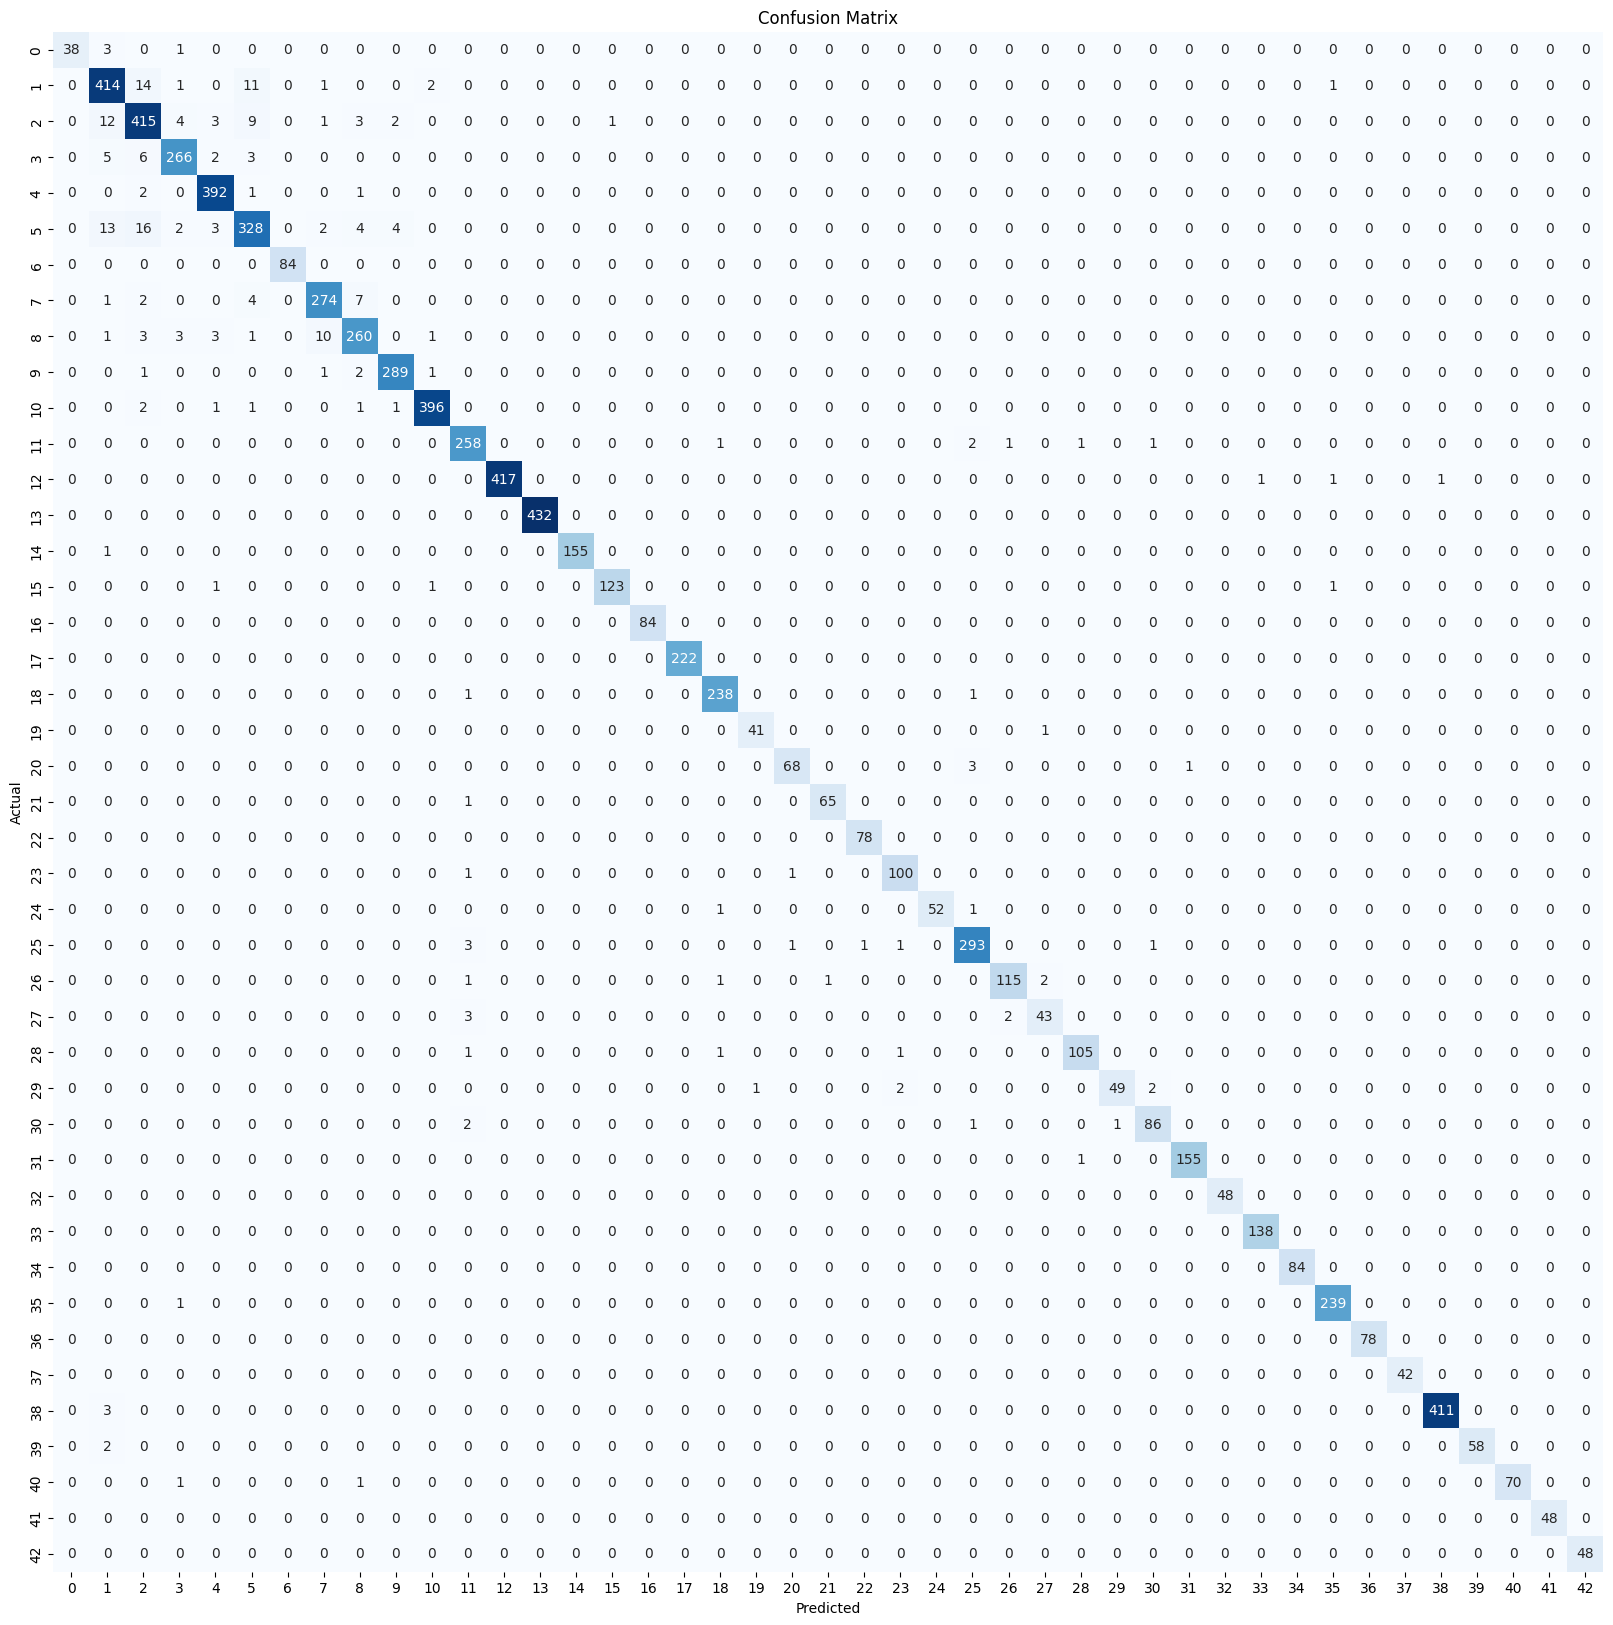

In [ ]:
# --- Vẽ Ma trận nhầm lẫn (Confusion Matrix) trực quan ---
print("\n--- Bước 2: Vẽ Ma trận nhầm lẫn (Confusion Matrix) trực quan ---")
cm = confusion_matrix(y_test, y_pred)


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


--- Bước 3: Phân tích Lỗi (Error Analysis) - Trực quan hóa hình ảnh bị sai ---


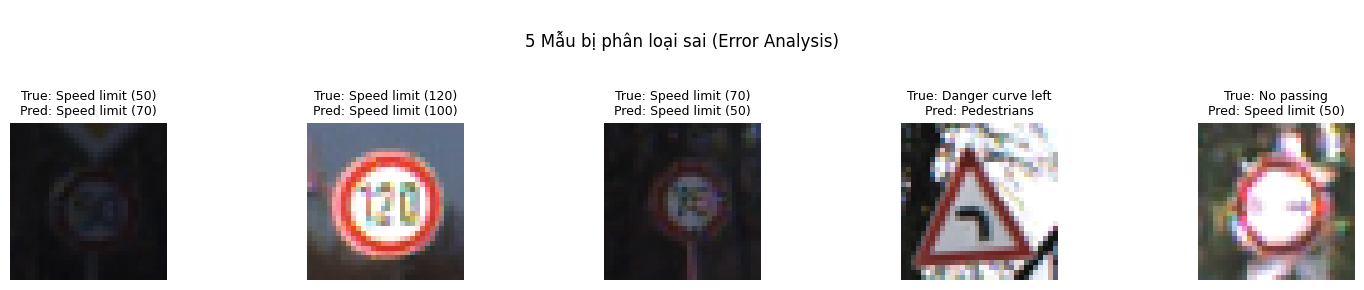

In [ ]:
# --- Phân tích Lỗi (Error Analysis) - Trực quan hóa hình ảnh bị sai ---
print("\n--- Bước 3: Phân tích Lỗi (Error Analysis) - Trực quan hóa hình ảnh bị sai ---")

# Tìm các chỉ số của các mẫu bị phân loại sai
misclassified_indices = np.where(y_pred != y_test)[0]

if len(misclassified_indices) == 0:
    print("Không có mẫu nào bị phân loại sai.")
else:
    # Lấy ngẫu nhiên 5 mẫu bị phân loại sai
    num_samples_to_show = min(5, len(misclassified_indices))
    random_misclassified_samples = random.sample(list(misclassified_indices), num_samples_to_show)

    plt.figure(figsize=(15, 3))
    for i, index in enumerate(random_misclassified_samples):
        plt.subplot(1, num_samples_to_show, i + 1)
        plt.imshow(X_test_raw[index]) # Hiển thị ảnh thô gốc
        true_label = CLASS_NAMES[y_test[index]]
        pred_label = CLASS_NAMES[y_pred[index]]
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)
        plt.axis('off')

    plt.suptitle(f"\n{num_samples_to_show} Mẫu bị phân loại sai (Error Analysis)", fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()


--- Bước 1: Tính toán và làm rỗng đường chéo chính ---
Đã tạo ma trận lỗi (error_cm) và làm rỗng đường chéo chính.

--- Bước 2: Trích xuất Top 10 cặp nhầm lẫn nhiều nhất ---
Top 10 cặp nhầm lẫn nhiều nhất:


,Nhãn thực tế (True Label),Nhãn dự đoán (Predicted),Tên biển báo thực tế,Tên biển báo dự đoán,Số lần nhầm lẫn
0,5,2,Speed limit (80),Speed limit (50),16
1,1,2,Speed limit (30),Speed limit (50),14
2,5,1,Speed limit (80),Speed limit (30),13
3,2,1,Speed limit (50),Speed limit (30),12
4,1,5,Speed limit (30),Speed limit (80),11
5,8,7,Speed limit (120),Speed limit (100),10
6,2,5,Speed limit (50),Speed limit (80),9
7,7,8,Speed limit (100),Speed limit (120),7
8,3,2,Speed limit (60),Speed limit (50),6
9,3,1,Speed limit (60),Speed limit (30),5



--- Bước 3: Vẽ biểu đồ ma trận lỗi ---


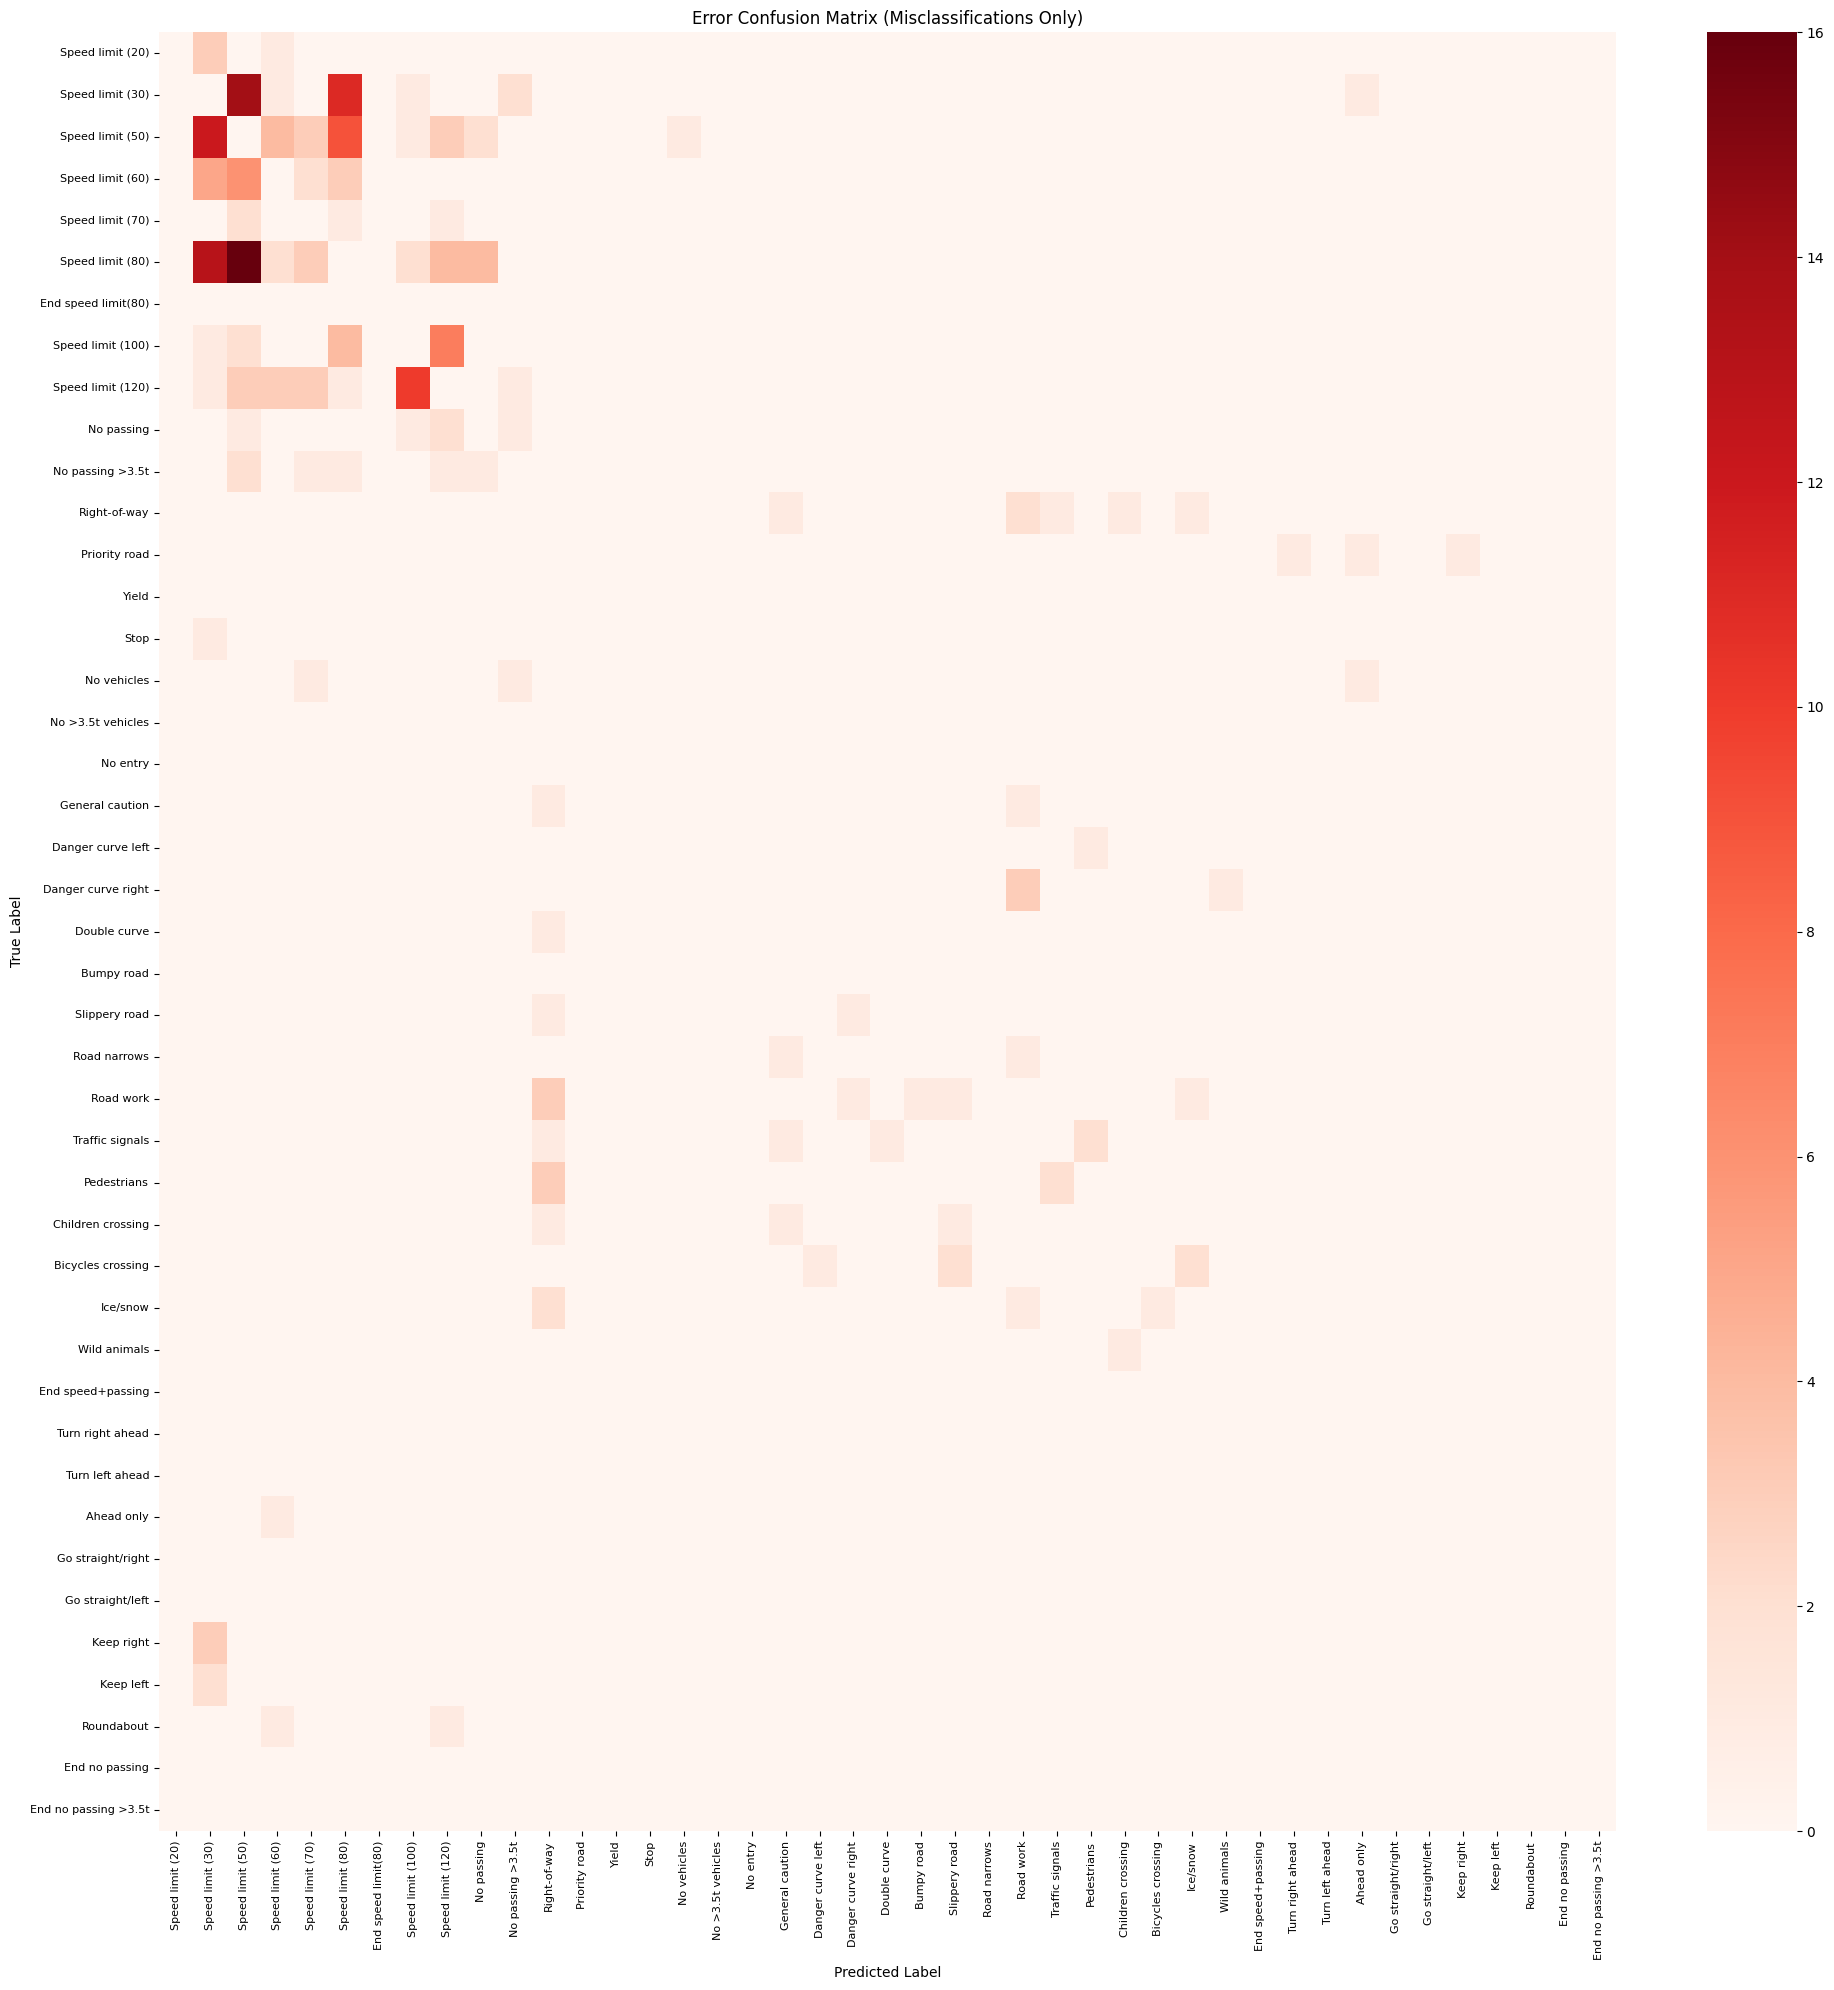

In [ ]:
print("\n--- Bước 1: Tính toán và làm rỗng đường chéo chính ---")
# cm đã được tính ở bước trước
error_cm = cm.copy()
np.fill_diagonal(error_cm, 0) # Gán giá trị trên đường chéo chính bằng 0
print("Đã tạo ma trận lỗi (error_cm) và làm rỗng đường chéo chính.")


print("\n--- Bước 2: Trích xuất Top 10 cặp nhầm lẫn nhiều nhất ---")

# Tìm tọa độ của các giá trị lớn nhất trong error_cm
# Sử dụng np.unravel_index để chuyển chỉ số phẳng thành chỉ số 2D (hàng, cột)
# Lấy 10 chỉ số lớn nhất
flat_indices = np.argsort(error_cm.ravel())[::-1][:10]
row_indices, col_indices = np.unravel_index(flat_indices, error_cm.shape)

# Tạo DataFrame để lưu kết quả
top_misclassifications = pd.DataFrame(columns=[
    'Nhãn thực tế (True Label)',
    'Nhãn dự đoán (Predicted)',
    'Tên biển báo thực tế',
    'Tên biển báo dự đoán',
    'Số lần nhầm lẫn'
])

for i in range(10):
    true_label_idx = row_indices[i]
    pred_label_idx = col_indices[i]
    count = error_cm[true_label_idx, pred_label_idx]

    # Lấy tên biển báo từ CLASS_NAMES
    true_sign_name = CLASS_NAMES[true_label_idx]
    pred_sign_name = CLASS_NAMES[pred_label_idx]

    top_misclassifications.loc[i] = [
        true_label_idx,
        pred_label_idx,
        true_sign_name,
        pred_sign_name,
        count
    ]

print("Top 10 cặp nhầm lẫn nhiều nhất:")
display(top_misclassifications)


print("\n--- Bước 3: Vẽ biểu đồ ma trận lỗi ---")
plt.figure(figsize=(20, 20))
sns.heatmap(error_cm, cmap='Reds', annot=False,
            xticklabels=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())],
            yticklabels=[CLASS_NAMES[i] for i in sorted(CLASS_NAMES.keys())])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Error Confusion Matrix (Misclassifications Only)')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

--- Bước 1: Chuẩn bị Ma trận Lỗi (Error Matrix) ---
Đã chuẩn bị cm_error với đường chéo chính bằng 0.

--- Bước 2: Gom cụm phân cấp (Hierarchical Clustering) ---
Đã thực hiện gom cụm phân cấp và trích xuất thứ tự sắp xếp mới.
Thứ tự sắp xếp mới (new_order): [10  0 38 35 14 39 29 22 24 31 21 19 40 33 42 41 37 36 34 32 17 16  6 13
 12 15 11 25 26 27 20 18 28 23 30  8  7  3  4  9  2  1  5]

--- Bước 3: Hoán vị và Vẽ biểu đồ (Reorder & Plot) ---


/tmp/ipykernel_1679/4238915071.py:28: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(sym_error, method='ward')


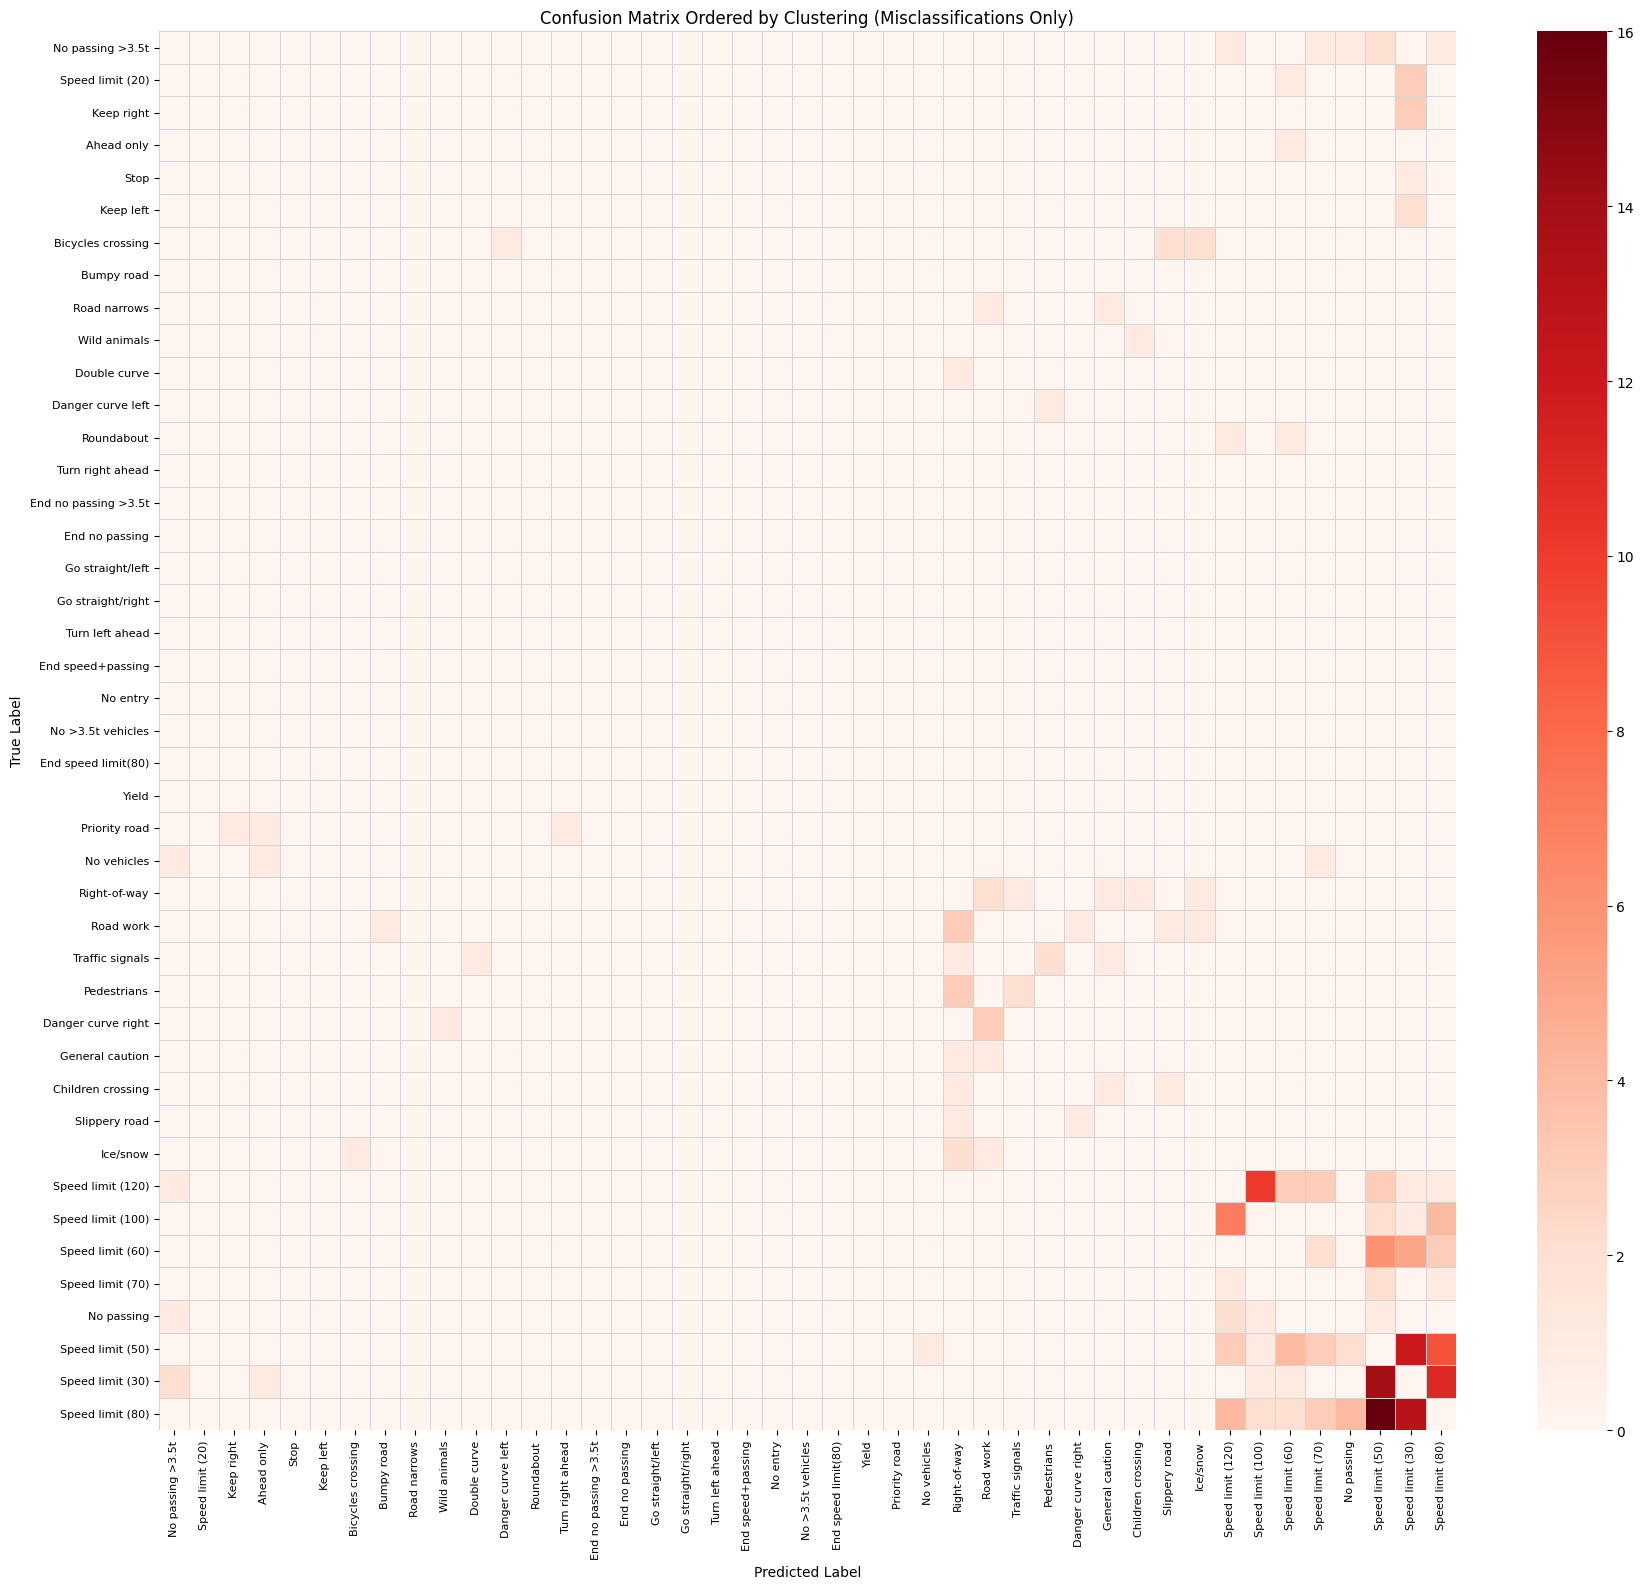


Biểu đồ ma trận nhầm lẫn đã được sắp xếp theo cụm phân cấp đã được hiển thị.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list

print("--- Bước 1: Chuẩn bị Ma trận Lỗi (Error Matrix) ---")
# cm đã được tính ở các bước trước từ y_test và y_pred

# Tạo bản sao và chuyển sang float
cm_error = cm.astype(float)

# Gán đường chéo chính bằng 0 để chỉ tập trung vào lỗi
np.fill_diagonal(cm_error, 0)
print("Đã chuẩn bị cm_error với đường chéo chính bằng 0.")

print("\n--- Bước 2: Gom cụm phân cấp (Hierarchical Clustering) ---")
# Tính ma trận đối xứng thể hiện mức độ nhầm lẫn qua lại.
# Mỗi hàng/cột của ma trận này đại diện cho một lớp và các giá trị trong hàng/cột đó
# cho biết mức độ nhầm lẫn của lớp đó với các lớp khác.
# Chúng ta sẽ gom cụm các lớp dựa trên sự tương đồng của các 'profile nhầm lẫn' này.
sym_error = cm_error + cm_error.T

# Thực hiện gom cụm phân cấp.
# Hàm linkage sẽ coi mỗi hàng của sym_error là một 'điểm dữ liệu' cho một lớp.
# Nó sẽ tính toán khoảng cách giữa các lớp dựa trên các profile nhầm lẫn này
# và tạo ra một cây phân cấp. method='ward' thường hoạt động tốt để tạo ra các cụm chặt chẽ.
linked = linkage(sym_error, method='ward')

# Trích xuất thứ tự sắp xếp mới từ cây phân cấp.
# leaves_list trả về một mảng các chỉ số gốc đã được hoán vị theo thứ tự của cây.
new_order = leaves_list(linked)
print("Đã thực hiện gom cụm phân cấp và trích xuất thứ tự sắp xếp mới.")
print(f"Thứ tự sắp xếp mới (new_order): {new_order}")

print("\n--- Bước 3: Hoán vị và Vẽ biểu đồ (Reorder & Plot) ---")
# Tạo ma trận nhầm lẫn mới đã được sắp xếp.
# Áp dụng new_order cho cả trục hàng và trục cột để đảm bảo các lớp được gom cụm
# nằm cạnh nhau trên cả hai chiều.
ordered_cm = cm_error[new_order, :][:, new_order]

# Tạo danh sách tên lớp theo thứ tự mới để hiển thị trên biểu đồ.
ordered_class_names = [CLASS_NAMES[i] for i in new_order]

# Vẽ heatmap của ma trận nhầm lẫn đã được sắp xếp.
plt.figure(figsize=(18, 16))
sns.heatmap(ordered_cm, cmap='Reds', annot=False,
            xticklabels=ordered_class_names,
            yticklabels=ordered_class_names,
            linewidths=.5, linecolor='lightgray') # Thêm đường viền để dễ nhìn hơn
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Ordered by Clustering (Misclassifications Only)')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

print("\nBiểu đồ ma trận nhầm lẫn đã được sắp xếp theo cụm phân cấp đã được hiển thị.")

Trích xuất HOG: 100%|██████████| 1/1 [00:00<00:00, 302.82it/s]


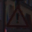

Dự đoán: General caution
Confidence Score: 42.3260


In [ ]:
from PIL import Image


test_image = '00143.png';
img = Image.open(TEST_DIR + '/' + test_image)
img = img.resize((32,32))
img_array = np.array(img)

# Extract HOG features for the single image
img_hog = extract_hog_features(np.array([img_array]))

# Scale the HOG features using the fitted scaler
img_scaled = scaler.transform(img_hog)

pred_label_idx = final_svm_model.predict(img_scaled)[0]

decision_scores = final_svm_model.decision_function(img_scaled)[0]
confidence_score = decision_scores[pred_label_idx]


img.thumbnail((150, 150))
display(img)

print(f"Dự đoán: {CLASS_NAMES[pred_label_idx]}")
print(f"Confidence Score: {confidence_score:.4f}")

In [ ]:
import time
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("\n--- Bước 1: Khởi tạo và Phân tích PCA ---")
# Mục tiêu giữ lại 95% phương sai của dữ liệu
pca = PCA(n_components=0.95, random_state=42)

# Thực hiện fit trên tập X_train_scaled
pca.fit(X_train_scaled)

# In ra số lượng vector riêng (components) được giữ lại
initial_dimensions = X_train_scaled.shape[1]
reduced_dimensions = pca.n_components_
print(f"Số lượng chiều ban đầu (HOG): {initial_dimensions}")
print(f"Số lượng chiều được giữ lại sau PCA (95% phương sai): {reduced_dimensions}")

print("\n--- Bước 2: Biến đổi dữ liệu (Transform) ---")
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Shape của X_train_pca: {X_train_pca.shape}")
print(f"Shape của X_test_pca: {X_test_pca.shape}")

print("\n--- Bước 3: Huấn luyện mô hình siêu tốc (Fast Training) ---")
start_time_pca_training = time.time()

# Khởi tạo lại một mô hình SVC với bộ tham số tối ưu đã tìm được trước đó
# (C=10, gamma='scale', kernel='rbf', class_weight='balanced')
final_svm_model_pca = SVC(
    C=10, gamma='scale', kernel='rbf', class_weight='balanced', random_state=42
)

# Huấn luyện .fit() mô hình này trên tập X_train_pca
final_svm_model_pca.fit(X_train_pca, y_train)

end_time_pca_training = time.time()

print("  Kết thúc huấn luyện mô hình SVC với PCA.")
training_time_pca = end_time_pca_training - start_time_pca_training
print(f"  Thời gian huấn luyện mô hình với PCA: {training_time_pca:.2f} giây")
start_time = time.time()
# Đánh giá lại .predict() trên X_test_pca và in ra Accuracy Score mới.
y_pred_pca = final_svm_model_pca.predict(X_test_pca)
svm_inference_time = time.time() - start_time

accuracy_pca = accuracy_score(y_test, y_pred_pca)


print(f"  Accuracy Score mới với PCA: {accuracy_pca:.4f}")

print("\n--- Phân tích kết quả --- ")
print(f"Thời gian huấn luyện ban đầu (không PCA): {76.24:.2f} giây") # Lấy từ output trước đó
print(f"Thời gian huấn luyện với PCA: {training_time_pca:.2f} giây")
print(f"Thời gian dự đoán của SVM (với PCA) trên toàn bộ tập test: {svm_inference_time:.4f} giây")
print(f"Accuracy ban đầu (không PCA): {0.9690:.4f}") # Lấy từ output trước đó
print(f"Accuracy với PCA: {accuracy_pca:.4f}")

if training_time_pca < 76.24 and accuracy_pca >= 0.96:
    print("\nKết luận: Việc sử dụng PCA đã giúp tăng tốc độ huấn luyện đáng kể trong khi vẫn duy trì được độ chính xác cao. Điều này cho thấy PCA đã tối ưu hóa không gian đặc trưng hiệu quả.")
elif training_time_pca < 76.24 and accuracy_pca < 0.96:
    print("\nKết luận: Việc sử dụng PCA đã giúp tăng tốc độ huấn luyện, nhưng độ chính xác có thể đã giảm nhẹ. Cần cân nhắc giữa tốc độ và độ chính xác.")
else:
    print("\nKết luận: Việc sử dụng PCA không cải thiện đáng kể tốc độ huấn luyện hoặc độ chính xác. Có thể cần điều chỉnh ngưỡng phương sai (n_components) hoặc xem xét các kỹ thuật giảm chiều khác.")



--- Bước 1: Khởi tạo và Phân tích PCA ---
Số lượng chiều ban đầu (HOG): 324
Số lượng chiều được giữ lại sau PCA (95% phương sai): 118

--- Bước 2: Biến đổi dữ liệu (Transform) ---
Shape của X_train_pca: (31367, 118)
Shape của X_test_pca: (7842, 118)

--- Bước 3: Huấn luyện mô hình siêu tốc (Fast Training) ---
  Kết thúc huấn luyện mô hình SVC với PCA.
  Thời gian huấn luyện mô hình với PCA: 35.73 giây
  Accuracy Score mới với PCA: 0.9677

--- Phân tích kết quả --- 
Thời gian huấn luyện ban đầu (không PCA): 76.24 giây
Thời gian huấn luyện với PCA: 35.73 giây
Thời gian dự đoán của SVM (với PCA) trên toàn bộ tập test: 45.6278 giây
Accuracy ban đầu (không PCA): 0.9690
Accuracy với PCA: 0.9677

Kết luận: Việc sử dụng PCA đã giúp tăng tốc độ huấn luyện đáng kể trong khi vẫn duy trì được độ chính xác cao. Điều này cho thấy PCA đã tối ưu hóa không gian đặc trưng hiệu quả.


In [ ]:
import joblib

joblib.dump(final_svm_model, '/content/drive/MyDrive/gtsrb_dataset/model.pkl')

['/content/drive/MyDrive/gtsrb_dataset/model.pkl']

In [ ]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("\n Khởi tạo và Huấn luyện KNN")
start_time_knn_training = time.time()

# Khởi tạo mô hình KNeighborsClassifier
# n_neighbors=5: Số lượng hàng xóm được xem xét
# metric='euclidean': Sử dụng khoảng cách Euclidean để tìm hàng xóm
# weights='distance': Gán trọng số cho hàng xóm dựa trên nghịch đảo khoảng cách (hàng xóm gần hơn có trọng số cao hơn)
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='distance')

# Huấn luyện mô hình trên tập dữ liệu đã qua PCA
knn_model.fit(X_train_pca, y_train)

end_time_knn_training = time.time()
training_time_knn = end_time_knn_training - start_time_knn_training
print(f"  Thời gian huấn luyện mô hình KNN: {training_time_knn:.2f} giây")

print("\n Dự đoán và Đánh giá")
start_time_knn_predict = time.time()

# Tiến hành dự đoán trên tập X_test_pca
y_pred_knn = knn_model.predict(X_test_pca)

end_time_knn_predict = time.time()
predict_time_knn = end_time_knn_predict - start_time_knn_predict
print(f"  Thời gian dự đoán (Inference time) của KNN trên toàn bộ tập test: {predict_time_knn:.4f} giây")

# Tính toán và in ra Accuracy Score
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"  Accuracy Score của mô hình KNN: {accuracy_knn:.4f}")

print("\n--- Tổng hợp so sánh ---")
# Lấy các giá trị từ kết quả của SVM trước đó
svm_training_time_pca = 44.84 # giây
svm_accuracy_pca = 0.9677

# Lưu ý: Thời gian dự đoán của SVM với PCA không được đo lường rõ ràng ở các bước trước.
# Chúng ta sẽ so sánh thời gian huấn luyện và độ chính xác.

print(f"\nSo sánh hiệu năng giữa KNN và SVM (với PCA):")
print(f"  Thời gian huấn luyện KNN: {training_time_knn:.2f} giây | Accuracy KNN: {accuracy_knn:.4f}")
print(f"  Thời gian huấn luyện SVM (với PCA): {svm_training_time_pca:.2f} giây | Accuracy SVM (với PCA): {svm_accuracy_pca:.4f}")

print(f"\nKết luận so sánh thời gian dự đoán (Inference time):")
# Do không có số liệu predict time cụ thể cho SVM với PCA, chúng ta chỉ có thể so sánh:
# Thường thì KNN có thể chậm hơn trong giai đoạn dự đoán với tập dữ liệu lớn hơn
# nếu không có các tối ưu hóa đặc biệt, do nó cần tính toán khoảng cách đến nhiều điểm dữ liệu.
# Với `weights='distance'`, KNN cần tính toán khoảng cách cho mỗi dự đoán.
# Đối với SVM, sau khi huấn luyện, việc dự đoán chỉ là tính toán dot product với các support vectors, thường nhanh hơn.
# Trong trường hợp này:
# KNN Predict Time: {predict_time_knn:.4f} giây
# Thời gian dự đoán của SVM (với PCA) không được đo trực tiếp trong các bước trước đó để so sánh chính xác.



if predict_time_knn < svm_inference_time:
    print("  Mô hình KNN dự đoán khá nhanh trên tập dữ liệu này.")
else:
    print("  Mô hình KNN dự đoán tương đối chậm trên tập dữ liệu này, chậm hơn so với dự đoán của SVM.")


 Khởi tạo và Huấn luyện KNN
  Thời gian huấn luyện mô hình KNN: 0.01 giây

 Dự đoán và Đánh giá
  Thời gian dự đoán (Inference time) của KNN trên toàn bộ tập test: 4.5750 giây
  Accuracy Score của mô hình KNN: 0.9634

--- Tổng hợp so sánh ---

So sánh hiệu năng giữa KNN và SVM (với PCA):
  Thời gian huấn luyện KNN: 0.01 giây | Accuracy KNN: 0.9634
  Thời gian huấn luyện SVM (với PCA): 44.84 giây | Accuracy SVM (với PCA): 0.9677

Kết luận so sánh thời gian dự đoán (Inference time):
  Mô hình KNN dự đoán khá nhanh trên tập dữ liệu này.


In [ ]:
# In ra tổng số lượng Support Vectors mà mô hình đã giữ lại
total_support_vectors = sum(final_svm_model_pca.n_support_)
print(f"Tổng số điểm Support Vectors: {total_support_vectors}")
print(f"Chiếm tỉ lệ: {(total_support_vectors / len(X_train_pca)) * 100:.2f}% tập huấn luyện")

Tổng số điểm Support Vectors: 18266
Chiếm tỉ lệ: 58.23% tập huấn luyện
